In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt


import sys
from pathlib import Path

project_root = Path().resolve().parent
src_path = project_root / "src"
sys.path.append(str(src_path))

import yaml
import h5py

from training.wno_training import EmulatorWNO

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## Model import

In [27]:
emulator_rep_path = project_root / "runs_mesu" / "RE90/RE90" / "wno_emul_lvl3_lay4_db6_norm_state_lr4"

with open(emulator_rep_path / "config.yaml", "r") as f:
    args = yaml.safe_load(f)

emulator = EmulatorWNO(width=args["width"],
                       level=args["level"],
                       layers=args["layers"],
                       size=args["n_dim"]*[args["res"]],
                       wavelet=args["wavelet"],
                       in_channel=args["input_dim"],
                       out_channel=args["output_dim"],
                       grid_range=args["domain_size"],
                       padding=args["padding"],
                       tau=args["tau"],
                       device=device)

emulator.load_state_dict(torch.load(emulator_rep_path / "model_weights/min_test_loss.pth", map_location=device)["model_state_dict"])
emulator = emulator.to(device)

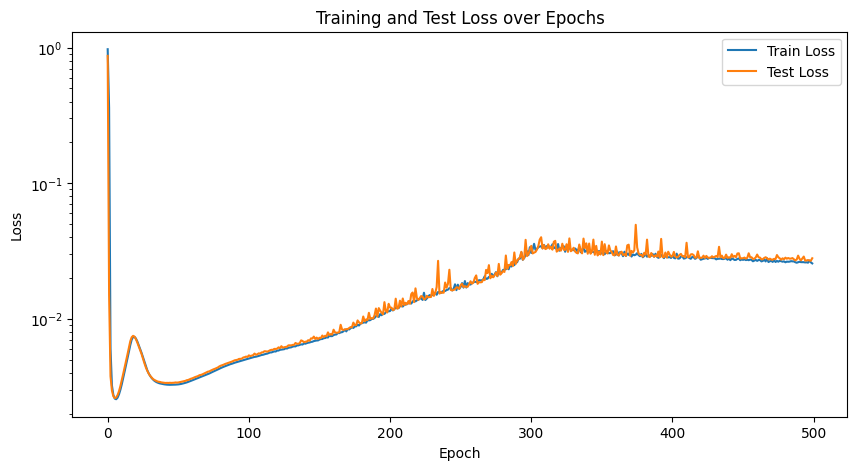

In [32]:
with open(emulator_rep_path / "logs/metrics.csv", "r") as f:
    lines = f.readlines()

header = lines[0].strip().split(",")
data = np.array([[float(v) for v in line.strip().split(",")] for line in lines[1:]])

epochs = np.arange(data.shape[0])

plt.figure(figsize=(10,5))
plt.semilogy(epochs, data[:, header.index("Tr loss")], label="Train Loss")
plt.semilogy(epochs, data[:, header.index("Te loss")], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epochs")
plt.legend();